## Import All Libraries

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

### Load Dataset

In [25]:
df = pd.read_csv("complated_clean_data.csv")
df.head()

,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,...,region_Central,region_East,region_North,region_South,region_West,employment_type_Retired,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed
0,0.640070,2.544216,0.056847,-1.353085,0.264743,-0.744091,-1.080157,1.281490,-0.794708,2.379502,...,0,0,0,1,0,0,1,0,0,0
1,-0.702181,-0.527484,-0.510177,-0.281153,0.264743,-0.934479,-2.243812,-1.044769,0.447023,0.863791,...,1,0,0,0,0,0,1,0,0,0
2,-0.031055,-0.095225,0.785877,-1.081397,-0.884685,-0.281721,-0.830803,0.436257,1.688754,0.863791,...,0,1,0,0,0,0,1,0,0,0
3,-0.798056,-0.141232,-2.033039,0.385717,1.988886,2.288516,1.579625,-0.342629,0.447023,2.379502,...,0,0,1,0,0,0,0,0,0,1
4,-0.031055,-0.013765,0.866880,0.118969,0.264743,1.322977,1.247152,0.597326,-0.794708,0.863791,...,0,1,0,0,0,0,0,1,0,0


### Features and Target

In [26]:
X = df.drop("risk_status", axis=1)

y = df["risk_status"]

### Encode Categorical Variables

In [27]:
X = pd.get_dummies(X,drop_first=True)

### Train Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

## Decision Tree

In [29]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [30]:
y_pred_dt = dt.predict(X_test)

y_prob_dt = dt.predict_proba(X_test)[:,1]

### Evaluation

In [31]:
print("Decision Tree")

print("Accuracy:",accuracy_score(y_test,y_pred_dt))

print("Precision:",precision_score(y_test,y_pred_dt))

print("Recall:",recall_score(y_test,y_pred_dt))

print("F1 Score:",f1_score(y_test,y_pred_dt))

Decision Tree
Accuracy: 0.9695652173913043
Precision: 0.8738738738738738
Recall: 0.8738738738738738
F1 Score: 0.8738738738738738


### Classification Report

In [32]:
print(classification_report(
    y_test,
    y_pred_dt
))

              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       809
         1.0       0.87      0.87      0.87       111

    accuracy                           0.97       920
   macro avg       0.93      0.93      0.93       920
weighted avg       0.97      0.97      0.97       920



### Confusion Matrix

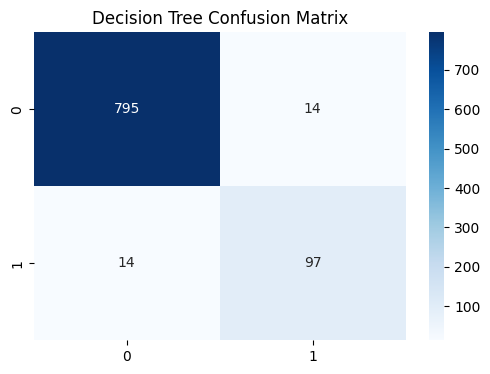

In [33]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

### Decision Tree Plot

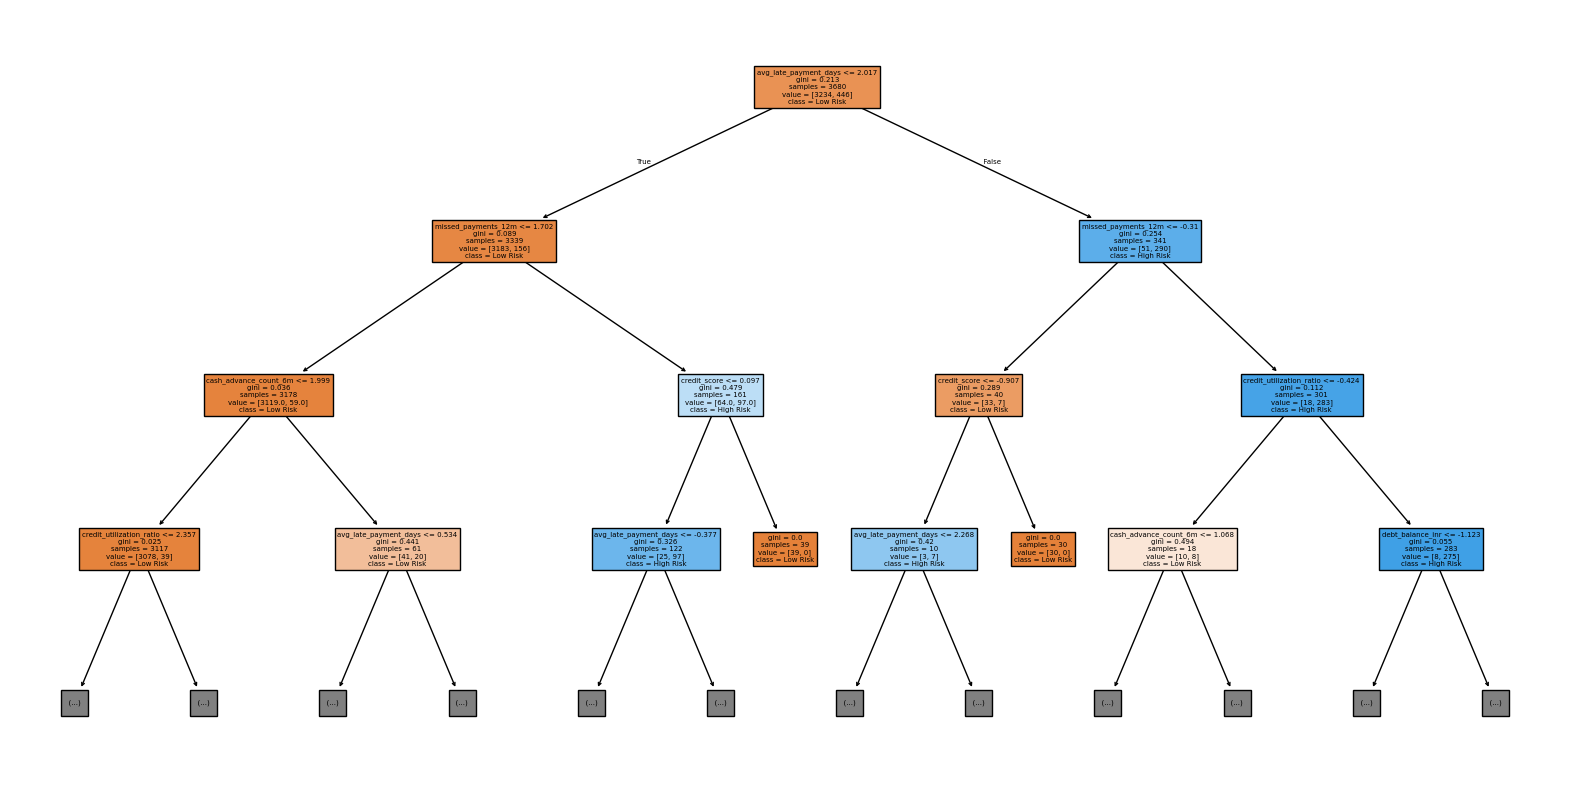

In [34]:
plt.figure(figsize=(20,10))

plot_tree(
    dt,
    filled=True,
    feature_names=X.columns,
    class_names=["Low Risk","High Risk"],
    max_depth=3
)

plt.show()

### Feature Importance

In [45]:
dt_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": dt.feature_importances_

})

dt_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
5,avg_late_payment_days,0.572739
4,missed_payments_12m,0.192432
2,credit_score,0.080217
3,credit_utilization_ratio,0.074400
8,cash_advance_count_6m,0.028733
10,failed_login_attempts_3m,0.017646
12,debt_balance_inr,0.009846
6,monthly_transaction_count,0.008055
1,annual_income_inr,0.006557
0,age,0.004496


## Random Forest

In [35]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

### Evaluation

In [37]:
print("Random Forest")

print("Accuracy:",accuracy_score(y_test,y_pred_rf))

print("Precision:",precision_score(y_test,y_pred_rf))

print("Recall:",recall_score(y_test,y_pred_rf))

print("F1 Score:",f1_score(y_test,y_pred_rf))

Random Forest
Accuracy: 0.9967391304347826
Precision: 0.9821428571428571
Recall: 0.990990990990991
F1 Score: 0.9865470852017937


### Classification Report

In [38]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       0.98      0.99      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



### Confusion Matrix

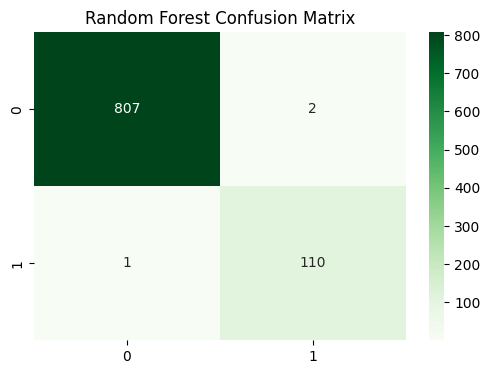

In [39]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")

plt.show()

### Feature Importance

In [40]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
5,avg_late_payment_days,0.304056
4,missed_payments_12m,0.174874
2,credit_score,0.106888
3,credit_utilization_ratio,0.103150
8,cash_advance_count_6m,0.092814
10,failed_login_attempts_3m,0.057772
1,annual_income_inr,0.049011
12,debt_balance_inr,0.026172
9,complaints_last_6m,0.022016
7,monthly_spend_inr,0.012910


## ROC-AUC Analysis

### Calculate AUC

In [41]:
dt_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Decision Tree AUC:", dt_auc)

print("Random Forest AUC:", rf_auc)

Decision Tree AUC: 0.9282842793349592
Random Forest AUC: 0.999916480138977


### ROC Curve

In [42]:
dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    y_prob_dt
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    y_prob_rf
)

### Combined ROC Curve

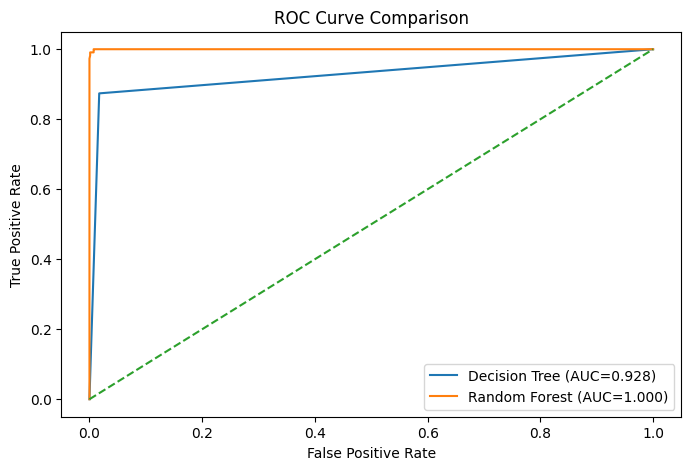

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC={dt_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### Model Comparison

In [44]:
comparison = pd.DataFrame({

    "Model":["Decision Tree","Random Forest"],

    "Accuracy":[
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf)
    ],

    "AUC":[dt_auc,rf_auc]
})

comparison

,Model,Accuracy,Recall,F1 Score,AUC
0,Decision Tree,0.969565,0.873874,0.873874,0.928284
1,Random Forest,0.996739,0.990991,0.986547,0.999916


## Conclusion

Decision Tree and Random Forest models were developed to classify customers into Low-Risk and High-Risk categories.

Both models were evaluated using Accuracy, Recall, F1 Score, Confusion Matrix, and ROC-AUC Score.

Feature importance analysis identified credit score, debt balance, missed payments, and credit utilization ratio as the most influential predictors.

Random Forest achieved higher Recall, F1 Score, and AUC Score than Decision Tree, indicating better classification performance and stronger ability to distinguish between high-risk and low-risk customers.

Therefore, Random Forest was selected as the best model for customer risk prediction.